### Create Gaussian Process around dataset

In [44]:
%load_ext autoreload
%autoreload 2

import pandas as pd

from agent.components.GaussianProcess import GASK
from agent.components.commons import ServiceType


s_type = ServiceType.QR
df = pd.read_csv("../statics/metrics_20_0.csv")
# 2. Initialize and train
gp = GASK(s_type, show_figures=False)
gp.init_models(df, density=1.0)

INFO:GP_Model:Fitting GP for elastic-workbench-qr-detector - Target: max_tp


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


INFO:multiscale:train_gp_models took 188 ms to execute


### Gaussian Process gives you µ,s for an arbitrary point

In [45]:
import numpy as np
%load_ext autoreload
%autoreload 2

# gp.predict(s_type, "max_tp", {'data_quality': 100, 'cores': 6.0})
# gp.predict(s_type, "max_tp", {'data_quality': 10000, 'cores': 600.0})
gp.predict(s_type, "max_tp", {'data_quality': 100, 'cores': 6.0, 'model_size': 2.0})

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


(np.float64(2050.112908336468), np.float64(145.8892622660747))

### Test if the global optimizer converges to a nice result

In [46]:
from agent.components.GaussianProcess import get_empirical_boundaries
%load_ext autoreload
%autoreload 2

from agent.components.Optimizer import local_obj, solve_global
from agent.components.SLORegistry_v2 import SLO_Registry

slo_lib = SLO_Registry("../statics/config/service_level_objectives.yml")
slos = slo_lib.get_slo_for_client("experiment-1", "client-1")

empirical_bounds = get_empirical_boundaries(gp.training_data)[s_type]
# print(empirical_bounds)

starting_point = [6.0, 400] + ([1.0] if s_type == ServiceType.CV else [])
# print(local_obj(starting_point, ServiceType.QR, slos, rask_gp, list(empirical_bounds.values())))
solve_global(s_type, slos, gp, last_assignments=starting_point)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


[np.float64(5.837459010220701), np.float64(869.5272067031685)]

### Test how much the epsilon should be moved each iteration

In [47]:
import numpy as np

# Convert to a numpy array so we can do math on the whole vector
x_norm = np.array([0.1] * (3 if s_type == ServiceType.CV else 2))
raw_bounds = get_empirical_boundaries(gp.training_data)[s_type]
del raw_bounds['max_tp']

# Store these to use for de-normalization inside the objective
ordered_bounds = list(raw_bounds.values())

for e in [1e-5, 1e-3, 1e-2, 5e-2]:
    # val_start uses the original center
    val_start = local_obj(x_norm, s_type, slos, gp, ordered_bounds)

    # x_norm + e now adds 'e' to every element (e.g., [0.11, 0.11])
    val_nudge = local_obj(x_norm + e, s_type, slos, gp, ordered_bounds)

    diff = abs(val_start - val_nudge)
    print(f"Eps {e}: Change in SLO-F is {diff:.6f}")

Eps 1e-05: Change in SLO-F is 0.000006
Eps 0.001: Change in SLO-F is 0.000599
Eps 0.01: Change in SLO-F is 0.006159
Eps 0.05: Change in SLO-F is 0.034222


Iteration 0: Elite found in bin (np.int64(1), np.int64(8)) with fitness 0.0940
Iteration 200: Elite found in bin (np.int64(6), np.int64(3)) with fitness 0.4589
Iteration 400: Elite found in bin (np.int64(5), np.int64(6)) with fitness 0.8027


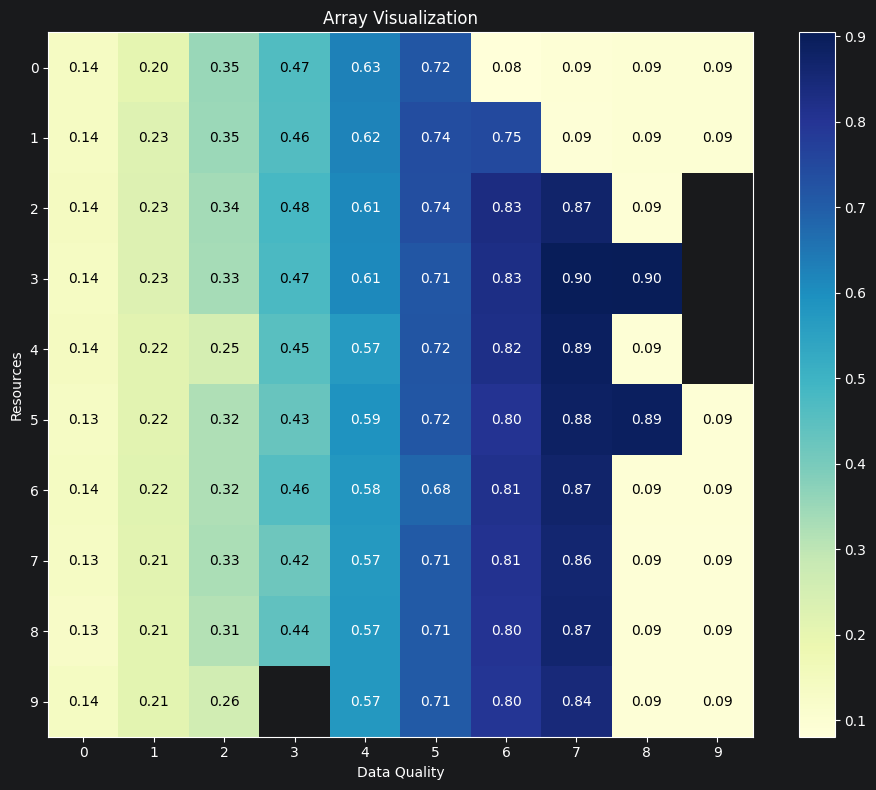

Versatile Candidate: {'coord': array([0.41542774, 0.90312924]), 'fitness': np.float64(0.904791221769019)}
Versatile Candidate: {'coord': array([0.71473416, 0.86518781]), 'fitness': np.float64(0.8707638450766018)}
Versatile Candidate: {'coord': array([0.91859292, 0.86871939]), 'fitness': np.float64(0.8660852145396574)}
Versatile Candidate: {'coord': array([0.16856642, 0.67067685]), 'fitness': np.float64(0.7491747312406014)}
Versatile Candidate: {'coord': array([0.54268074, 0.66344388]), 'fitness': np.float64(0.7194962554806407)}
Versatile Candidate: {'coord': array([0.86562327, 0.66600446]), 'fitness': np.float64(0.7077747639484286)}
Versatile Candidate: {'coord': array([0.36984256, 0.55449697]), 'fitness': np.float64(0.6102950604361204)}
Versatile Candidate: {'coord': array([0.04209419, 0.41883066]), 'fitness': np.float64(0.465365577853056)}
Versatile Candidate: {'coord': array([0.72001284, 0.44368551]), 'fitness': np.float64(0.45885781444567747)}
Versatile Candidate: {'coord': array([

In [48]:
from utils import visualize_ndarray
from agent.components.Optimizer import VersatileMapElites

# 1. Initialize
v_me = VersatileMapElites(s_type, bins=10)

# TODO: Fix the black cells in the table
# 2. Run the illumination
v_me.run_search(slos, gp, ordered_bounds, iterations=1000)
visualize_ndarray(v_me.fitness_table)

# 3. Get 5 solutions that are high-performing but far apart
diverse_set = v_me.get_diverse_set(n_solutions=10, versatility=0.2)

# 4. De-normalize for your agent
for sol in diverse_set:
    # real_val = [sol[i] * (ordered_bounds[i][1] - ordered_bounds[i][0]) + ordered_bounds[i][0]
    #             for i in range(2)]
    print(f"Versatile Candidate: {sol}")

# TODO: Add axis labels